In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file_path = "battleship_game_squares.csv"  
df = pd.read_csv(file_path)
df.head()


,id,ai_mode_id,autoplay,ai_win,ai_ships,square,games
0,1,3,0,0,0,1,4561
1,2,3,0,0,0,2,4257
2,3,3,0,0,0,3,4311
3,4,3,0,0,0,4,4069
4,5,3,0,0,0,5,4111


In [3]:
square_games = df.groupby("square")["games"].sum().reset_index()

square_games.head()


,square,games
0,1,15269
1,2,16989
2,3,19657
3,4,20225
4,5,20839


In [7]:
grid_size = 10
heatmap_data = np.zeros((grid_size, grid_size))


for _, row in square_games.iterrows():
    square = row["square"] - 1  # Convert to 0-based index
    x, y = divmod(square, grid_size)  
    heatmap_data[x, y] = row["games"]

# Flip the rows to match 'A' at the top (reverse row order)
heatmap_data = np.flipud(heatmap_data)

# Display the reshaped matrix
heatmap_data


array([[14295., 17200., 19875., 20262., 20620., 20035., 19621., 19040.,
        17276., 15292.],
       [16608., 18148., 19967., 20751., 20948., 20923., 20302., 19592.,
        17589., 17074.],
       [19349., 19835., 20731., 21096., 21408., 21368., 20975., 20634.,
        19351., 19351.],
       [20307., 21236., 21649., 21924., 22282., 22273., 21753., 21455.,
        20452., 20121.],
       [20828., 21661., 21804., 22238., 22750., 22824., 22023., 21511.,
        20755., 20824.],
       [21247., 21532., 21597., 22158., 22813., 22923., 22045., 21662.,
        20940., 21104.],
       [20819., 21115., 21333., 21855., 22099., 22274., 21860., 21431.,
        21020., 20940.],
       [20207., 20093., 20703., 21374., 21361., 21374., 21111., 20714.,
        20030., 20341.],
       [17266., 18183., 19873., 20855., 21168., 21174., 20959., 20008.,
        18365., 17602.],
       [15269., 16989., 19657., 20225., 20839., 20461., 19976., 19346.,
        17029., 14516.]])

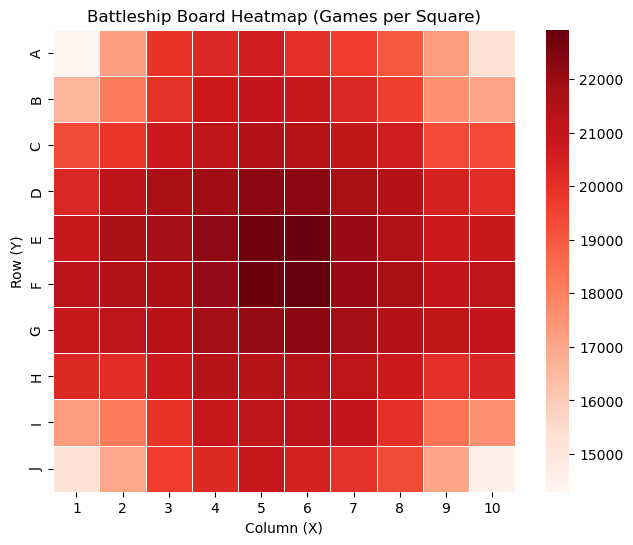

In [8]:
# Create row labels (A-J from top to bottom) and column labels (1-10)
row_labels = [chr(i) for i in range(ord('A'), ord('A') + grid_size)]
col_labels = [str(i) for i in range(1, grid_size + 1)]

# Plot the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, cmap="Reds", annot=False, linewidths=0.5, square=True, xticklabels=col_labels, yticklabels=row_labels)

# Labels and title
plt.title("Battleship Board Heatmap (Games per Square)")
plt.xlabel("Column (X)")
plt.ylabel("Row (Y)")

plt.show()
